# Paper figures — Sorcha

Figures for the Rubin-cadence Sorcha section of the NEOrocks paper.

**Kernel:** `neofast_py310` (`/astro/users/ds2004/.conda/envs/neofast_py310/bin/python`).

**Figures in this notebook:**
1. Sky-coverage tracklet-density map (Mollweide, equatorial) — the "base LSST survey" figure.

Output PNGs are written to `Figures/` (the Overleaf graphics path).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import healpy as hp
from astropy.coordinates import SkyCoord, BarycentricMeanEcliptic, ICRS
import astropy.units as u

%matplotlib inline

## Figure: sky-coverage tracklet-density map

Mollweide map (equatorial coords) of the tracklet surface density, in the style of
Wagg et al. (2025) and Kurlander et al. The dense ecliptic-following band is the
Wide-Fast-Deep (WFD) survey; the sharp northern edge near $\delta\approx+5^\circ$ and
the sparser coverage above it (the Northern Ecliptic Spur) are real features of the
Rubin cadence.

**Preview note:** this uses the Arnor comparison subsample
(`outputs/phase2/sorcha_comparison.parquet`; earlier 2-yr window, antisun-footprint,
non-NEO tracklets for a faithful footprint). For the publication figure, point `INPUT`
at the full Hyak v5.0 tracklet set and set `DROP_NEO = False` (the full set is unbiased).

In [2]:
# ---- config ----
INPUT      = "outputs/phase2/sorcha_comparison.parquet"   # Hyak v5.0: outputs/tracklets_v5/...
OUTPUT     = "Figures/sorcha_sky_coverage_smoothed.png"
RA_COL, DEC_COL = "mean_ra", "mean_dec"
NSIDE      = 64        # HEALPix resolution (equal-area pixels, ~0.84 deg^2)
DROP_NEO   = True      # exclude oversampled NEOs in the comparison subsample
SMOOTH_DEG = 1.5       # Gaussian smoothing FWHM (deg); 0 = none
TITLE      = "Sorcha simulated tracklet density (2-yr Rubin cadence)"  # "" for caption-only

In [3]:
# ---- load tracklets ----
try:
    df = pd.read_parquet(INPUT, columns=[RA_COL, DEC_COL, "population"])
    has_pop = True
except Exception:
    df = pd.read_parquet(INPUT, columns=[RA_COL, DEC_COL])
    has_pop = False

if DROP_NEO and has_pop:
    df = df[df.population != "NEO"]

ra  = df[RA_COL].to_numpy()
dec = df[DEC_COL].to_numpy()
print(f"{len(ra):,} tracklets")

497,229 tracklets


In [4]:
# ---- bin onto HEALPix -> tracklets per square degree ----
npix      = hp.nside2npix(NSIDE)
pix_area  = hp.nside2pixarea(NSIDE, degrees=True)
counts    = np.bincount(hp.ang2pix(NSIDE, ra, dec, lonlat=True), minlength=npix).astype(float)
dens      = counts / pix_area
if SMOOTH_DEG > 0:
    dens = hp.smoothing(np.nan_to_num(dens), fwhm=np.radians(SMOOTH_DEG))
    dens[dens < 0] = 0
dens[counts == 0] = np.nan        # blank empty pixels

print(f"covered: {100*np.isfinite(dens).mean():.1f}% of sky | density/sqdeg: "
      f"{np.nanmin(dens):.2f}-{np.nanmax(dens):.1f}")

covered: 50.7% of sky | density/sqdeg: 0.23-182.0


In [5]:
# ---- ecliptic plane (lat=0) in equatorial RA/Dec ----
# Sort by RA and break the line at the RA=180 map edge so newprojplot does not draw a
# spurious connector straight across the map. Longitude is passed in [-180, 180].
elon = np.linspace(0, 360, 2000)
ecl  = SkyCoord(lon=elon * u.deg, lat=np.zeros_like(elon) * u.deg,
                frame=BarycentricMeanEcliptic).transform_to(ICRS())
e_ra, e_dec = ecl.ra.deg, ecl.dec.deg
o = np.argsort(e_ra)
e_ra, e_dec = e_ra[o], e_dec[o]
ecl_lon180 = ((e_ra + 180) % 360) - 180
brk = np.where(np.abs(np.diff(ecl_lon180)) > 180)[0]
ecl_lon180 = np.insert(ecl_lon180, brk + 1, np.nan)
ecl_dec    = np.insert(e_dec,      brk + 1, np.nan)

<Figure size 1100x600 with 0 Axes>

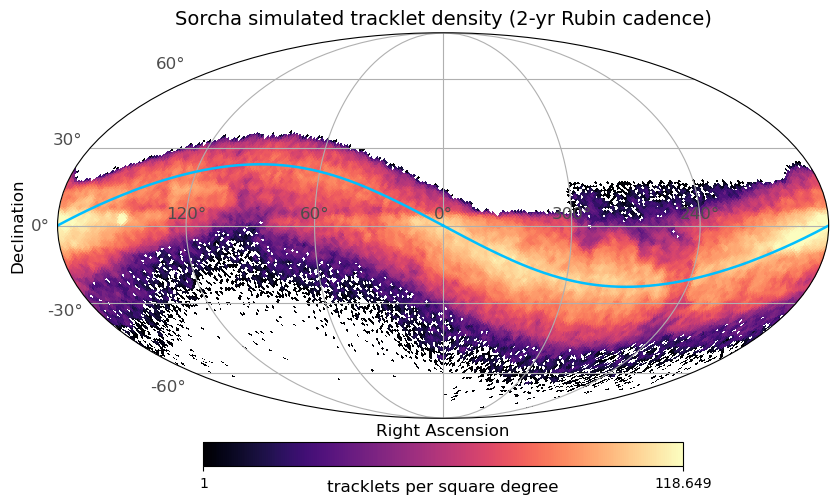

saved Figures/sorcha_sky_coverage_smoothed.png


In [9]:
# ---- render ----
vmin = max(np.nanpercentile(dens, 2), 1.0)
vmax = np.nanpercentile(dens, 99.5)

plt.figure(figsize=(11, 6))
hp.projview(
    dens, coord=["C"], projection_type="mollweide", flip="astro",
    cmap="magma", norm="log", min=vmin, max=vmax,
    graticule=True, graticule_labels=True,
    xlabel="Right Ascension", ylabel="Declination",
    unit="tracklets per square degree", cb_orientation="horizontal",
    title=TITLE, badcolor="white", bgcolor="white",
    xtick_label_color="0.3", ytick_label_color="0.3",
)
hp.newprojplot(theta=np.radians(90 - ecl_dec), phi=np.radians(ecl_lon180),
               color="deepskyblue", lw=1.8)
plt.savefig(OUTPUT, dpi=200, bbox_inches="tight", facecolor="white")
plt.show()
print("saved", OUTPUT)

### Regenerating the publication version (when Hyak is back)

Set in the config cell:
```python
INPUT    = "outputs/tracklets_v5/<...>.parquet"   # or a concatenation of the v5 grid tracklets
OUTPUT   = "Figures/sorcha_sky_coverage_v5.png"
DROP_NEO = False                                  # full v5 set is unbiased
```
and re-run. The same code is also available as the standalone script
`make_sky_coverage_figure.py`.

When you swap in the v5.0 data, glance that the WFD northern edge is still near
$\delta\approx+5^\circ$ (it can shift a degree or two between cadence versions) and update
the figure caption if needed.